In [1]:
import pandas as pd
pd.options.display.max_columns = None

df = pd.read_csv('../data/bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [2]:
df['y'].value_counts(normalize=True)

y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64

1. Jika cost FN lebih tinggi maka saya akan menggunakan Recall daripada Precision karena
2. Kalo kita push Recall ke 100% maka precision bisa menjadi semakin kecil, dan orang yang ditelpon akan menjadi sia-sia karena model salah menebak calon nasabah
3. Karena F1-Score menyeimbangkan antara Recall dan Precision agar model tidak bias

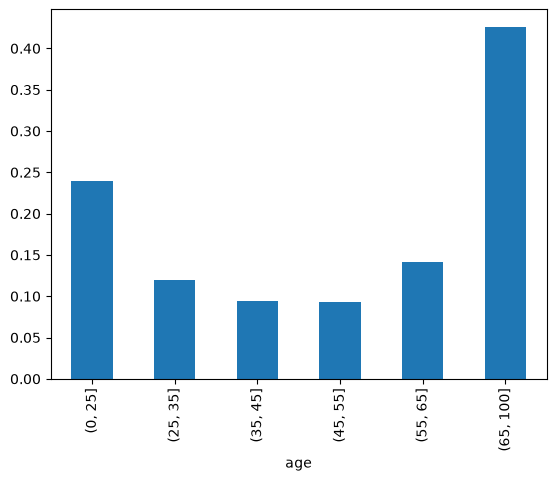

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# age, balance, campaign, previous

pd.cut(df['age'], bins=[0,25,35,45,55,65,100]).pipe(lambda b: df.groupby(b)['y'].apply(lambda x: (x=='yes').mean())).plot(kind='bar');

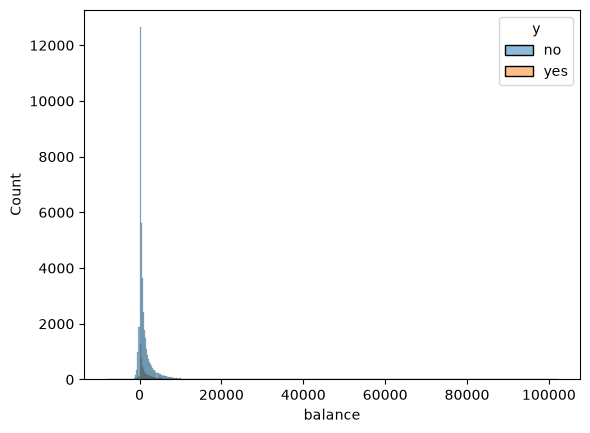

In [4]:
sns.histplot(x=df.balance, hue=df.y);

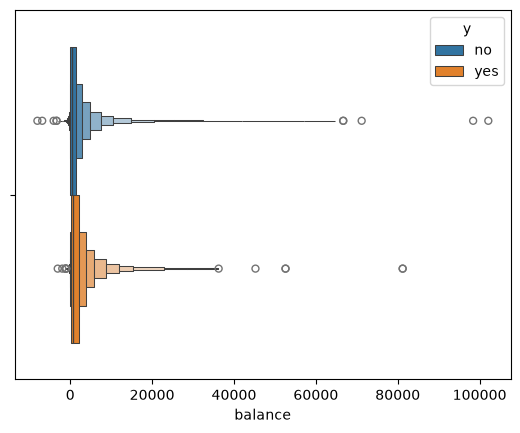

In [5]:
sns.boxenplot(x=df.balance, hue=df.y);

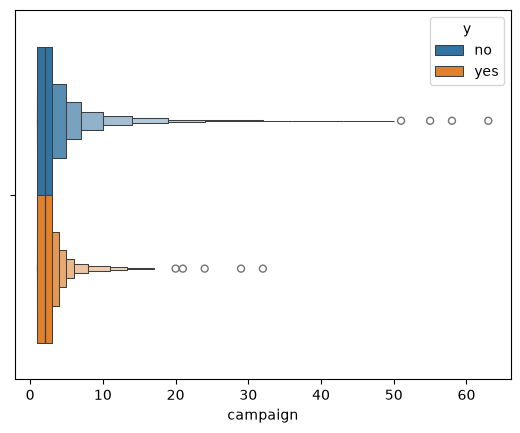

In [6]:
sns.boxenplot(x=df.campaign, hue=df.y);

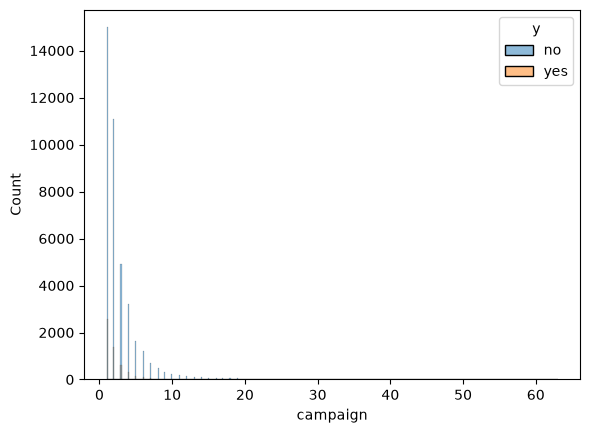

In [7]:
sns.histplot(x=df.campaign, hue=df.y);

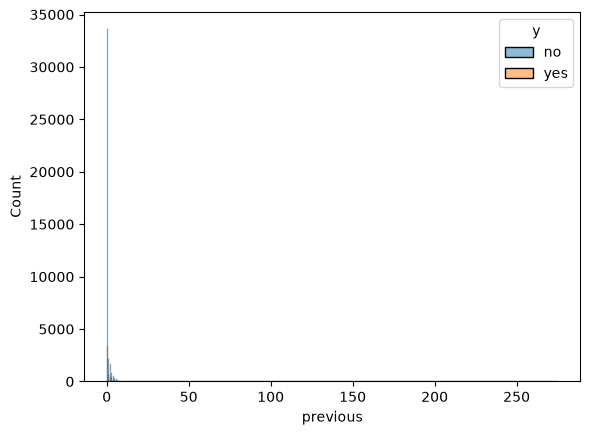

In [8]:
sns.histplot(x=df.previous, hue=df.y);

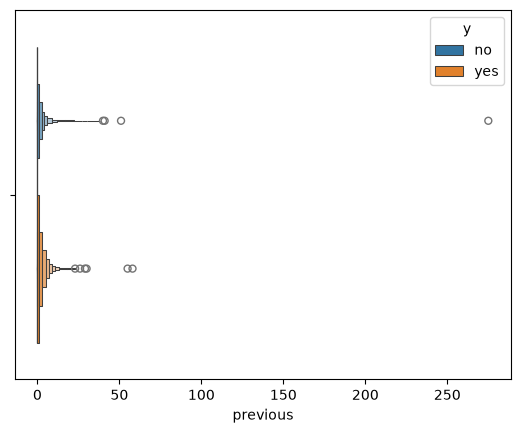

In [9]:
sns.boxenplot(x=df.previous, hue=df.y);

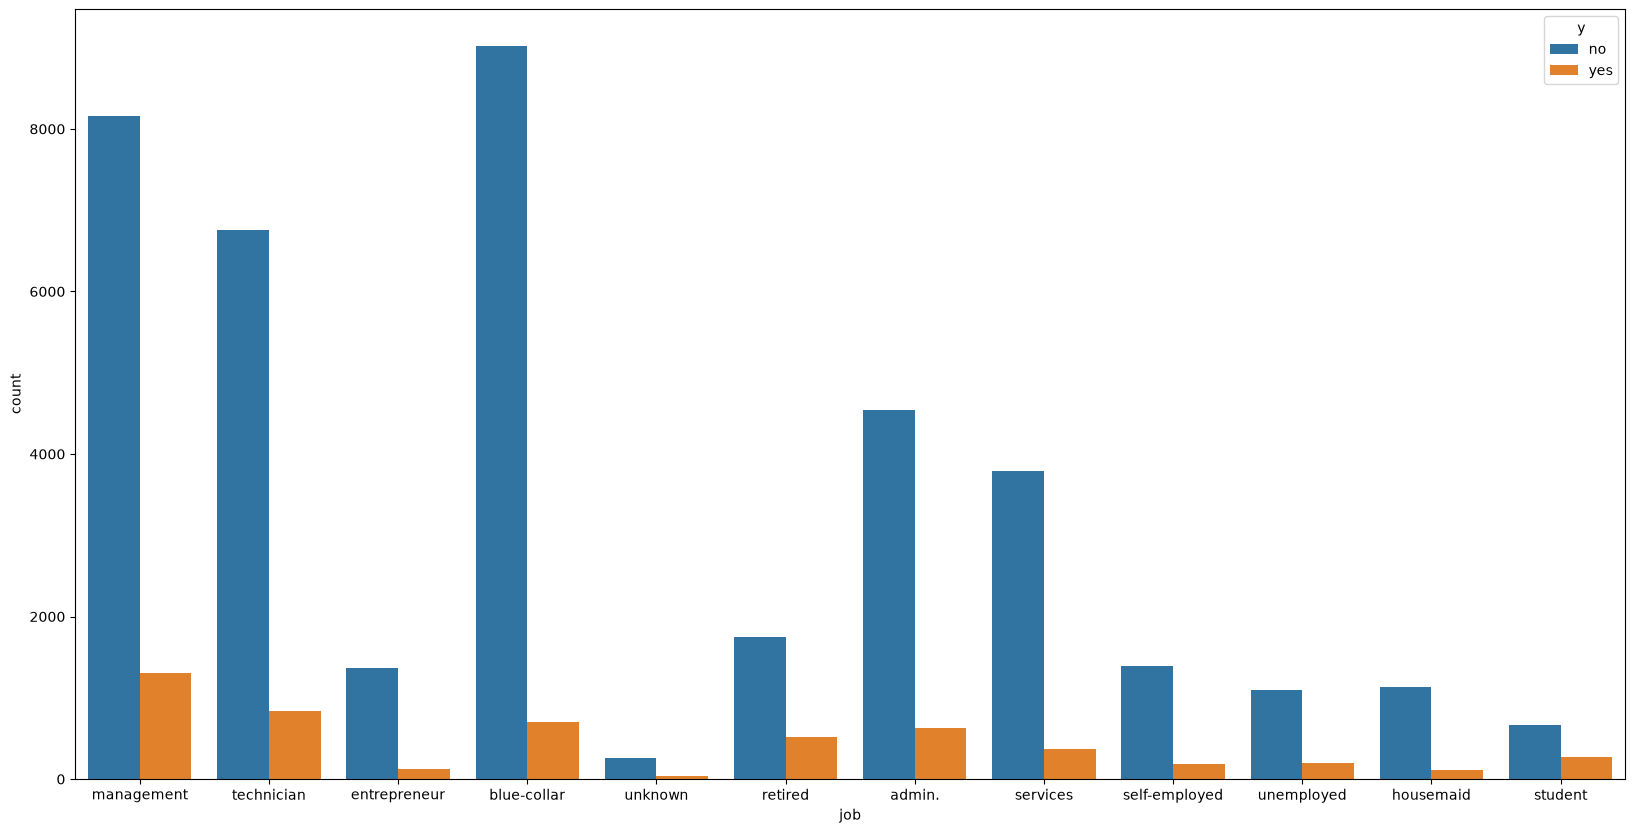

In [10]:
# job, marital, education, poutcome, month.
plt.figure(figsize=(20,10))
sns.countplot(x=df.job, hue=df.y);

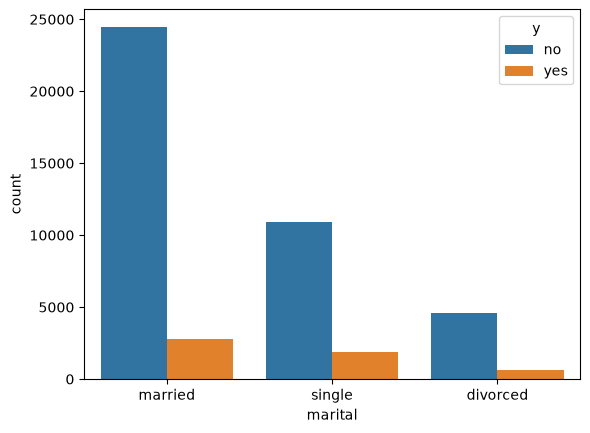

In [11]:
sns.countplot(x=df.marital, hue=df.y);

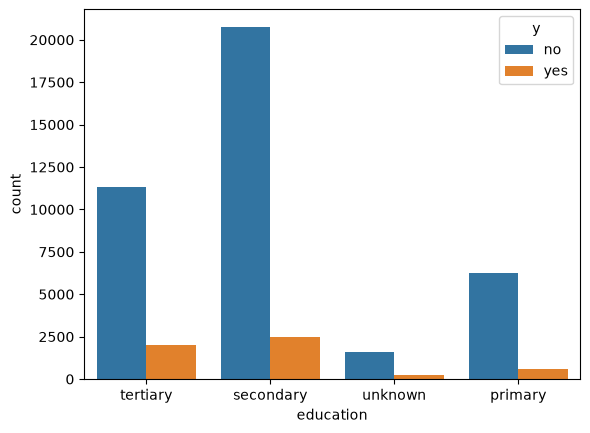

In [12]:
sns.countplot(x=df.education, hue=df.y);


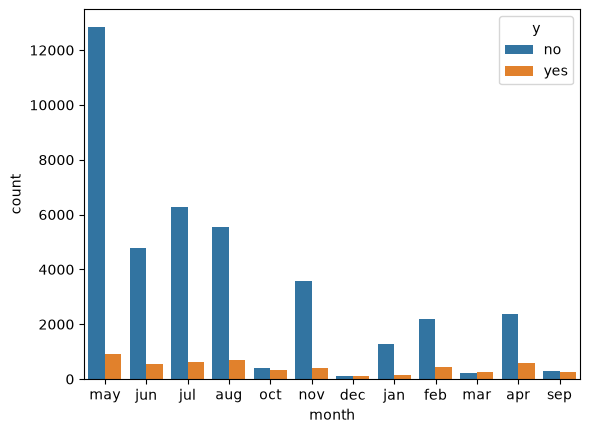

In [13]:
sns.countplot(x=df.month, hue=df.y);

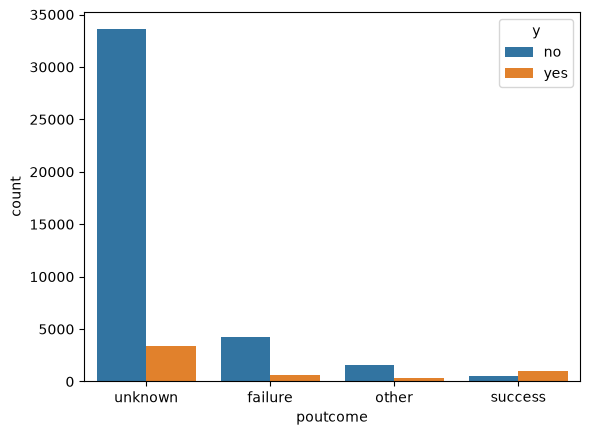

In [14]:
sns.countplot(x=df.poutcome, hue=df.y);

<Axes: >

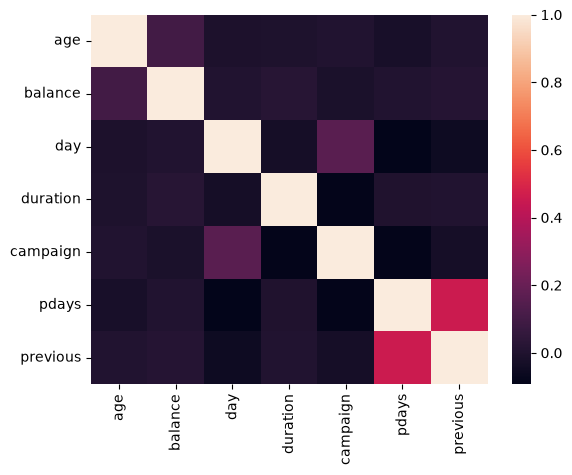

In [15]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr)

In [16]:
# subscribe RATE per kategori, bukan count
df.groupby('job')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64

In [17]:
df.groupby('education')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)


education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: y, dtype: float64

In [18]:
df.groupby('marital')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)


marital
single      0.149492
divorced    0.119455
married     0.101235
Name: y, dtype: float64

In [19]:
df.groupby('poutcome')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

poutcome
success    0.647253
other      0.166848
failure    0.126097
unknown    0.091615
Name: y, dtype: float64

In [20]:
df.groupby('month')['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)


month
mar    0.519916
dec    0.467290
sep    0.464594
oct    0.437669
apr    0.196794
feb    0.166478
aug    0.110133
jun    0.102228
nov    0.101511
jan    0.101212
jul    0.090935
may    0.067195
Name: y, dtype: float64

In [21]:

# untuk age, coba bikin bin dulu
pd.cut(df['age'], bins=[0,25,35,45,55,65,100]).pipe(lambda b: df.groupby(b)['y'].apply(lambda x: (x=='yes').mean()))

age
(0, 25]      0.239521
(25, 35]     0.120031
(35, 45]     0.093894
(45, 55]     0.093527
(55, 65]     0.141239
(65, 100]    0.426099
Name: y, dtype: float64

1. `poutcome=success` → 64.7% subscribe, ~5.5x lipat dari baseline. Predictor paling kuat di dataset — wajar, orang yang sudah pernah convert di campaign sebelumnya jauh lebih reseptif.
2. `Age` punya pola U-shaped, bukan linear: usia 65+ (42.6%) dan di bawah 25 (24%) jauh di atas baseline, sementara usia produktif 35-55 malah di bawah baseline (~9%). Pensiunan dan anak muda/mahasiswa lebih reseptif terhadap term deposit dibanding orang usia kerja-keluarga.
3. `job=student` (28.7%) dan `job=retired` (22.8%) adalah dua kategori pekerjaan tertinggi — selaras sama temuan age di atas. Sebaliknya blue-collar (7.3%) dan entrepreneur (8.3%) paling rendah.
4. Month sangat musiman: Maret (52%), Desember (46.7%), September (46.5%), Oktober (43.8%) jauh di atas baseline — padahal biasanya ini bulan dengan volume kontak kecil. Sebaliknya Mei (6.7%) justru terendah meski (dari EDA count lu sebelumnya) volume kontaknya paling besar. Ini sinyal kuat: kuantitas kontak ≠ kualitas timing.
5. `education=tertiary` (15%) dan `marital=single` (14.9%) sedikit di atas baseline, tapi efeknya jauh lebih lemah dibanding poutcome, month, atau age.

### Leakage Check

count    45211.000000
mean       258.163080
std        257.527812
min          0.000000
25%        103.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


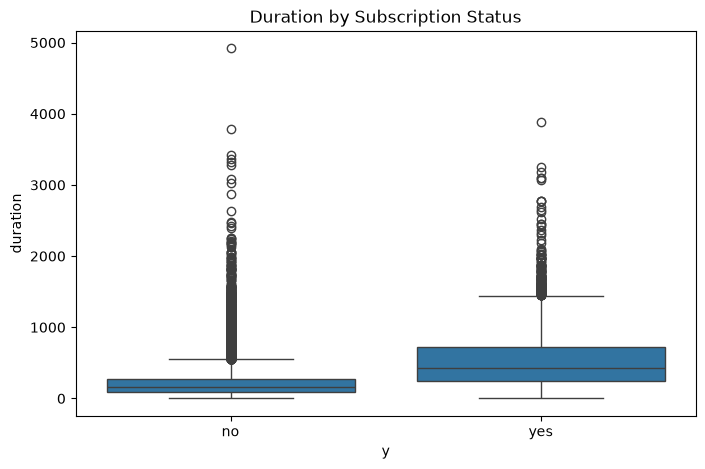

y
no     221.182806
yes    537.294574
Name: duration, dtype: float64
y
no     164.0
yes    426.0
Name: duration, dtype: float64


In [25]:
print(df['duration'].describe())

plt.figure(figsize=(8,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Duration by Subscription Status')
plt.show()

print(df.groupby('y')['duration'].mean())
print(df.groupby('y')['duration'].median())

Secara rata-rata durasi nasabah yang berlangganan lebih lama dalam panggilan. durasi lama panggilan sekitar 8 menit. Namun `duration` ini baru ada nilainya SETELAH telepon selesai, kalau kita masukkan `duration` sebagai feature training, model akan belajar pola "kalau telepon lama = yes". Jadi fitur ini akan kita drop/buang ketika `Model Training`

In [26]:
# Cek distribusi pdays
print(df['pdays'].value_counts().head(10))
print((df['pdays'] == -1).sum(), "dari", len(df), "baris")

# Cek hubungan pdays == -1 dengan previous
print(df[df['pdays'] == -1]['previous'].value_counts())

# Cek hubungan pdays == -1 dengan poutcome
print(df[df['pdays'] == -1]['poutcome'].value_counts())

pdays
-1      36954
 182      167
 92       147
 91       126
 183      126
 181      117
 370       99
 184       85
 364       77
 95        74
Name: count, dtype: int64
36954 dari 45211 baris
previous
0    36954
Name: count, dtype: int64
poutcome
unknown    36954
Name: count, dtype: int64


Berdasarkan dari informasi data dokumentasi dataset -1 adalah orang yang belum dihubungi sebelumnya. Fitur `pdays==-1`, kalau nasabah belum pernah dikontak sebelumnya `previous==0`, otomatis gak ada "hari sejak kontak terakhir" `pdays==-1` dan otomatis gak ada "hasil campaign terakhir" `poutcome==unknown`. Tiga kolom ini saling konsisten, bukan saling leak. Kalau dibiarkan sebagai angka -1 dan dimasukkan ke model sebagai fitur numerik biasa, model bisa salah interpretasi seolah -1 itu "lebih kecil" dari semua hari positif (padahal artinya "kategori berbeda total"). 